<a href="https://colab.research.google.com/github/Duq0/EPL_EDA/blob/main/EPL_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


## Importing data

In [ ]:
data = pd.read_csv('/content/merged_22-25.csv')
epl_df = pd.DataFrame(data)
epl_df.head(5)

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,IWA,VCH,VCD,VCA,IWCH,IWCD,IWCA,VCCH,VCCD,VCCA
0,E0,15/08/2025,20:00,Liverpool,Bournemouth,4,2,H,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,E0,16/08/2025,12:30,Aston Villa,Newcastle,0,0,D,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,E0,16/08/2025,15:00,Brighton,Fulham,1,1,D,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,E0,16/08/2025,15:00,Sunderland,West Ham,3,0,H,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,E0,16/08/2025,15:00,Tottenham,Burnley,3,0,H,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data cleaning

### Selecting columns of interest

In [ ]:
epl_data = epl_df[['Date','Time','HomeTeam','AwayTeam','FTHG','FTAG','HTHG','HTAG','FTR']].copy()
epl_data.head(5)

,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,HTHG,HTAG,FTR
0,15/08/2025,20:00,Liverpool,Bournemouth,4,2,1,0,H
1,16/08/2025,12:30,Aston Villa,Newcastle,0,0,0,0,D
2,16/08/2025,15:00,Brighton,Fulham,1,1,0,0,D
3,16/08/2025,15:00,Sunderland,West Ham,3,0,0,0,H
4,16/08/2025,15:00,Tottenham,Burnley,3,0,1,0,H


In [ ]:
# detect null values
epl_data.isnull().sum()

,0
Date,0
Time,0
HomeTeam,0
AwayTeam,0
FTHG,0
FTAG,0
HTHG,0
HTAG,0
FTR,0


In [ ]:
# detect duplicates
epl_data.duplicated().sum()

np.int64(0)

In [ ]:
epl_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1441 entries, 0 to 1440
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      1441 non-null   object
 1   Time      1441 non-null   object
 2   HomeTeam  1441 non-null   object
 3   AwayTeam  1441 non-null   object
 4   FTHG      1441 non-null   int64 
 5   FTAG      1441 non-null   int64 
 6   HTHG      1441 non-null   int64 
 7   HTAG      1441 non-null   int64 
 8   FTR       1441 non-null   object
dtypes: int64(4), object(5)
memory usage: 101.4+ KB


In [ ]:
# convert date to datetime
epl_data['Date'] = pd.to_datetime(epl_data['Date'])
epl_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1441 entries, 0 to 1440
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      1441 non-null   datetime64[ns]
 1   Time      1441 non-null   object        
 2   HomeTeam  1441 non-null   object        
 3   AwayTeam  1441 non-null   object        
 4   FTHG      1441 non-null   int64         
 5   FTAG      1441 non-null   int64         
 6   HTHG      1441 non-null   int64         
 7   HTAG      1441 non-null   int64         
 8   FTR       1441 non-null   object        
dtypes: datetime64[ns](1), int64(4), object(4)
memory usage: 101.4+ KB


/tmp/ipykernel_3347/188723949.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  epl_data['Date'] = pd.to_datetime(epl_data['Date'])


### removing outliers

In [ ]:
# how many games has a team played?
home_games = epl_data['HomeTeam'].value_counts()
away_games = epl_data['AwayTeam'].value_counts()

total_games_played = home_games.add(away_games, fill_value=0).sort_values(ascending=False)
print('Total games played by each team (Top 10):\n', total_games_played.head(10))
print('\nTotal games played by each team (Bottom 10):\n', total_games_played.tail(10))

Total games played by each team (Top 10):
 Arsenal           145
Wolves            145
Aston Villa       144
Brentford         144
Bournemouth       144
Chelsea           144
Crystal Palace    144
Everton           144
Brighton          144
West Ham          144
Name: count, dtype: int64

Total games played by each team (Bottom 10):
 Newcastle           144
Liverpool           144
Leicester            76
Southampton          76
Burnley              68
Leeds                68
Luton                38
Ipswich              38
Sheffield United     38
Sunderland           30
Name: count, dtype: int64


The bottom 8 teams have played significantly less games, explaining their low performance. We will remove them for now.

In [ ]:
# remove the bottom 8 teams from epl_data
bottom_8_teams = total_games_played.tail(8).index
epl_data = epl_data[~epl_data['HomeTeam'].isin(bottom_8_teams)]
epl_data = epl_data[~epl_data['AwayTeam'].isin(bottom_8_teams)]
epl_data.head(5)

,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,HTHG,HTAG,FTR
0,2025-08-15,20:00,Liverpool,Bournemouth,4,2,1,0,H
1,2025-08-16,12:30,Aston Villa,Newcastle,0,0,0,0,D
2,2025-08-16,15:00,Brighton,Fulham,1,1,0,0,D
5,2025-08-16,17:30,Wolves,Man City,0,4,0,2,A
6,2025-08-17,14:00,Chelsea,Crystal Palace,0,0,0,0,D


In [ ]:
# verifying changes
home_games = epl_data['HomeTeam'].value_counts()
away_games = epl_data['AwayTeam'].value_counts()

total_games_played = home_games.add(away_games, fill_value=0).sort_values(ascending=False)
print('Total games played by each team (Top 10):\n', total_games_played.tail(10))

Total games played by each team (Top 10):
 Bournemouth       121
Brentford         121
Man City          121
Fulham            121
Everton           121
Chelsea           121
West Ham          121
Newcastle         121
Crystal Palace    120
Liverpool         120
Name: count, dtype: int64


with the outliers removed, each team has played about 121 games.

## Stats on the data

In [ ]:
epl_data.shape

(1032, 9)

there is a total of 1441 games played from 2022 to 2025

In [ ]:
# count of unique teams
unique_teams = epl_data['HomeTeam'].unique()
print(f'There are {len(unique_teams)} unique teams')

There are 17 unique teams


In [ ]:

# make a winner team column
conditions = [
    epl_data['FTR'] == 'H',
    epl_data['FTR'] == 'A'
]
choices = [
    epl_data['HomeTeam'],
    epl_data['AwayTeam']
]
epl_data['Winner'] = np.select(conditions, choices, default='Draw')
epl_data.head(5)

,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,HTHG,HTAG,FTR,Winner
0,2025-08-15,20:00,Liverpool,Bournemouth,4,2,1,0,H,Liverpool
1,2025-08-16,12:30,Aston Villa,Newcastle,0,0,0,0,D,Draw
2,2025-08-16,15:00,Brighton,Fulham,1,1,0,0,D,Draw
5,2025-08-16,17:30,Wolves,Man City,0,4,0,2,A,Man City
6,2025-08-17,14:00,Chelsea,Crystal Palace,0,0,0,0,D,Draw


FTR
H    467
A    315
D    250
Name: count, dtype: int64


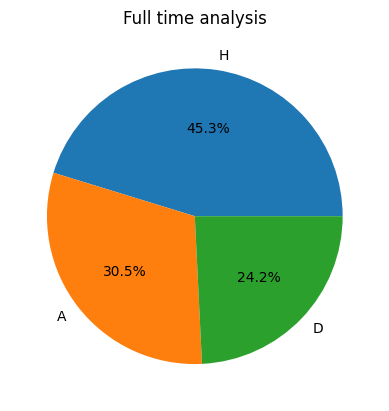

In [ ]:
full_time_analysis = epl_data['FTR'].value_counts()
print(full_time_analysis)
plt.pie(full_time_analysis, labels=full_time_analysis.index, autopct='%1.1f%%')
plt.title('Full time analysis')
plt.show()

Most matches that have been won have been home games.

In [ ]:
winners = epl_data['Winner'].value_counts().sort_values()
winners.drop('Draw', inplace=True)
print(winners)

Winner
Wolves            29
West Ham          30
Nott'm Forest     31
Crystal Palace    33
Everton           35
Bournemouth       36
Brentford         38
Fulham            39
Tottenham         41
Brighton          45
Chelsea           50
Man United        51
Newcastle         53
Aston Villa       57
Liverpool         65
Man City          74
Arsenal           75
Name: count, dtype: int64


Arsenal has the most wins, 75 wins in 122 matches, that is a 61% winrate.


### plotting

/tmp/ipykernel_3347/11595428.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=winners, palette='rainbow')


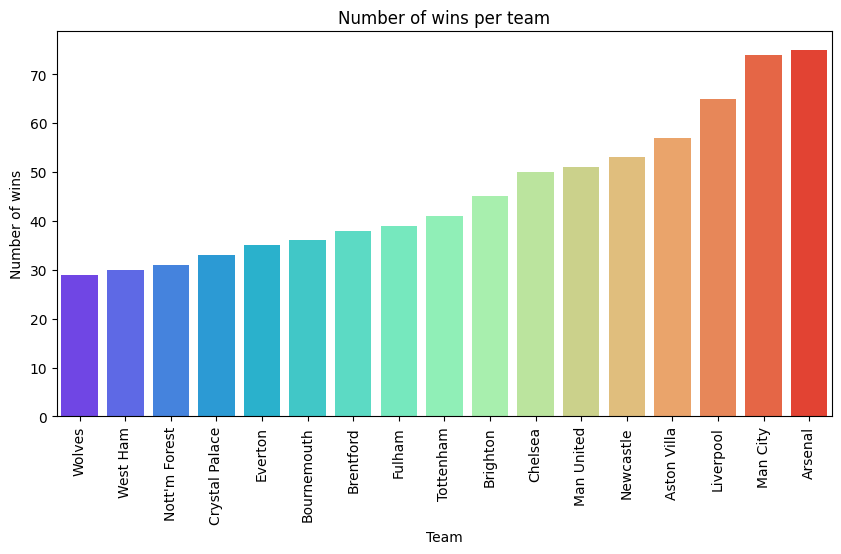

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(data=winners, palette='rainbow')
plt.title('Number of wins per team')
plt.xlabel('Team')
plt.ylabel('Number of wins')
plt.xticks(rotation=90)
plt.show()

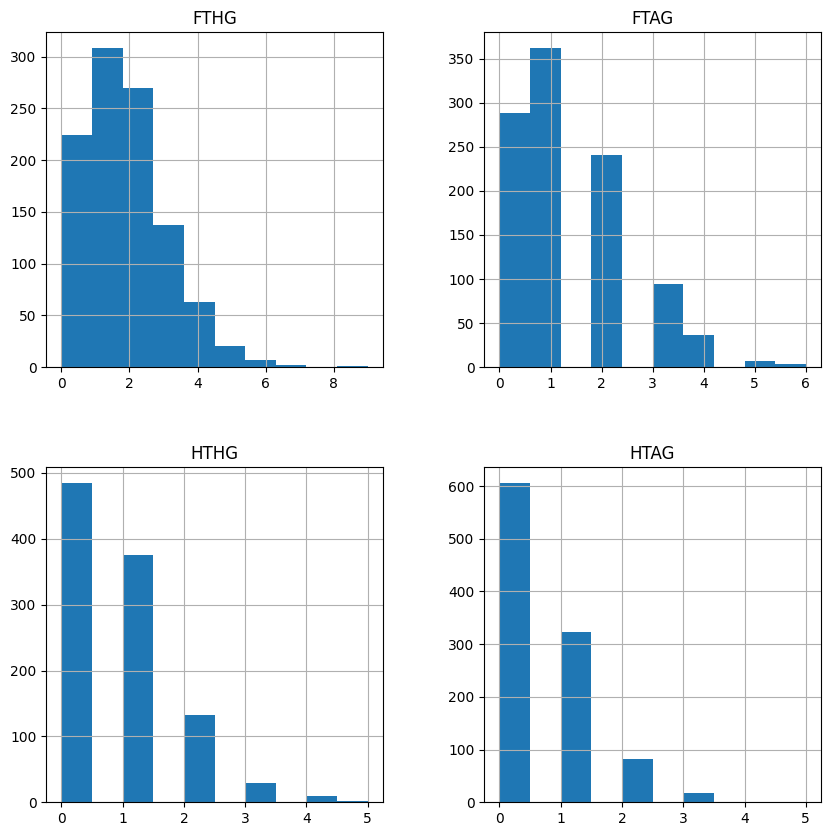

In [ ]:
numeric_columns = epl_data.select_dtypes(include=[np.number])
numeric_columns.hist(figsize=(10,10))
plt.show()

In most matches, have 0 goals at half-time and atleast 1 goal at full-time

In [ ]:
# Calculate Home Wins, Away Wins, Draws, and Losses for each team
top5 = winners.tail(5)
bottom5 = winners.head(5)
team_stats = []
teams_of_interest = np.concatenate((top5.index, bottom5.index))
for team in teams_of_interest:
    home_wins = epl_data[(epl_data['HomeTeam'] == team) & (epl_data['FTR'] == 'H')].shape[0]
    away_wins = epl_data[(epl_data['AwayTeam'] == team) & (epl_data['FTR'] == 'A')].shape[0]
    draws = epl_data[((epl_data['HomeTeam'] == team) | (epl_data['AwayTeam'] == team)) & (epl_data['FTR'] == 'D')].shape[0]

    home_losses = epl_data[(epl_data['HomeTeam'] == team) & (epl_data['FTR'] == 'A')].shape[0]
    away_losses = epl_data[(epl_data['AwayTeam'] == team) & (epl_data['FTR'] == 'H')].shape[0]
    total_losses = home_losses + away_losses

    team_stats.append({
        'Team': team,
        'Home Wins': home_wins,
        'Away Wins': away_wins,
        'Draws': draws,
        'Losses': total_losses
    })

team_stats_df = pd.DataFrame(team_stats)
team_stats_df = team_stats_df.set_index('Team').sort_values(by=['Home Wins', 'Away Wins', 'Draws', 'Losses'], ascending=[False, False, False, True])
display(team_stats_df)

,Home Wins,Away Wins,Draws,Losses
Team,,,,
Man City,43,31,25,22
Arsenal,42,33,29,18
Liverpool,42,23,30,25
Aston Villa,37,20,24,41
Newcastle,35,18,27,41
Wolves,20,9,27,68
Everton,18,17,34,52
Nott'm Forest,18,13,31,60
Crystal Palace,17,16,39,48


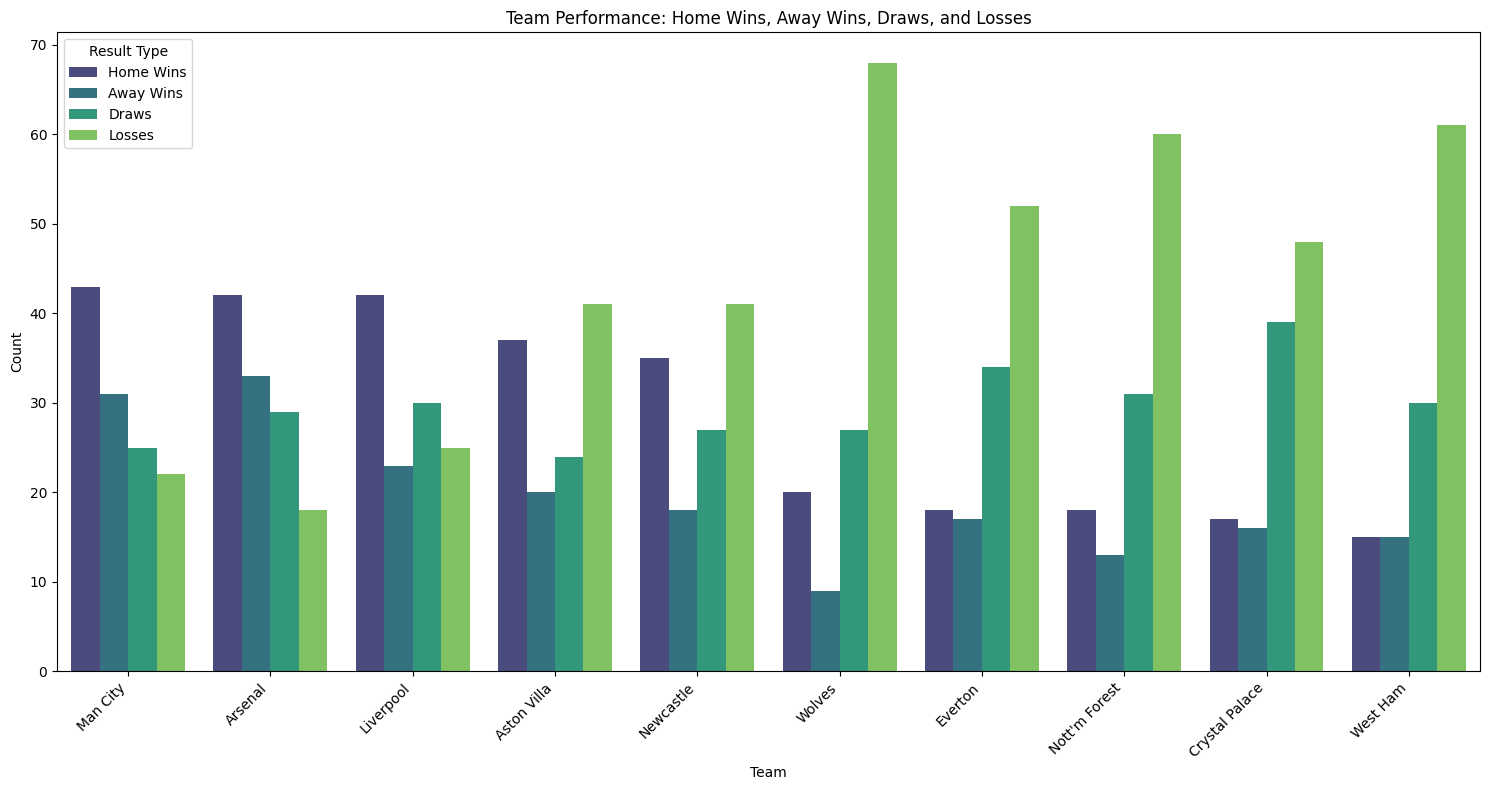

In [ ]:
team_stats_df_reset = team_stats_df.reset_index()

# Melt the DataFrame to long format, including 'Losses'
team_stats_all_melted = team_stats_df_reset.melt(
    id_vars=['Team'],
    value_vars=['Home Wins', 'Away Wins', 'Draws', 'Losses'],
    var_name='Statistic Type',
    value_name='Count'
)

plt.figure(figsize=(15, 8))
sns.barplot(
    data=team_stats_all_melted,
    x='Team',
    y='Count',
    hue='Statistic Type',
    palette='viridis'
)
plt.title('Team Performance: Home Wins, Away Wins, Draws, and Losses')
plt.xlabel('Team')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Result Type')
plt.tight_layout()
plt.show()

This compares top 5 vs bottom 5 teams outcomes.

### Calculating Team Points

In [ ]:
# Calculate points for each match
def calculate_points(row):
    if row['FTR'] == 'H':
        return row['HomeTeam'], 3
    elif row['FTR'] == 'A':
        return row['AwayTeam'], 3
    else:
        return None, 1 # For draws, both teams get 1 point

team_points = {}
for index, row in epl_data.iterrows():
    winner_team, points = calculate_points(row)

    # Award points to the winning team or both teams for a draw
    if winner_team:
        team_points[winner_team] = team_points.get(winner_team, 0) + points
    else: # It's a draw
        team_points[row['HomeTeam']] = team_points.get(row['HomeTeam'], 0) + 1
        team_points[row['AwayTeam']] = team_points.get(row['AwayTeam'], 0) + 1

# Convert to DataFrame for better visualization and sorting
team_points_df = pd.DataFrame(team_points.items(), columns=['Team', 'Points'])
team_points_df = team_points_df.sort_values(by='Points', ascending=False).reset_index(drop=True)

display(team_points_df.head(10))

,Team,Points
0,Arsenal,254
1,Man City,247
2,Liverpool,225
3,Aston Villa,195
4,Newcastle,186
5,Chelsea,183
6,Man United,177
7,Brighton,168
8,Brentford,147
9,Tottenham,145


### Visualizing Team Points

/tmp/ipykernel_3347/3724550349.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Team', y='Points', data=team_points_df, palette='viridis')


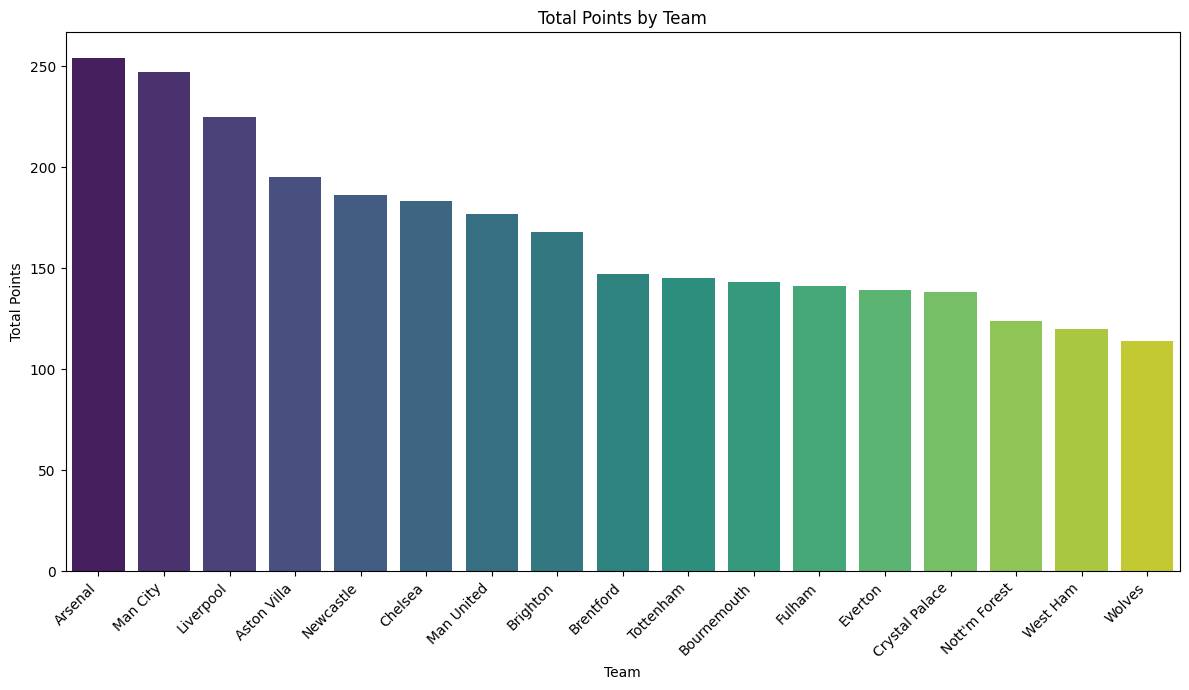

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Team', y='Points', data=team_points_df, palette='viridis')
plt.title('Total Points by Team')
plt.xlabel('Team')
plt.ylabel('Total Points')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Calculating Goal Difference

In [ ]:
team_goals = {}

for index, row in epl_data.iterrows():
    home_team = row['HomeTeam']
    away_team = row['AwayTeam']
    home_goals = row['FTHG']
    away_goals = row['FTAG']

    # Update goals for home team
    team_goals[home_team] = team_goals.get(home_team, {'Goals For': 0, 'Goals Against': 0})
    team_goals[home_team]['Goals For'] += home_goals
    team_goals[home_team]['Goals Against'] += away_goals

    # Update goals for away team
    team_goals[away_team] = team_goals.get(away_team, {'Goals For': 0, 'Goals Against': 0})
    team_goals[away_team]['Goals For'] += away_goals
    team_goals[away_team]['Goals Against'] += home_goals

# Convert to DataFrame and calculate Goal Difference
goal_stats_df = pd.DataFrame.from_dict(team_goals, orient='index')
goal_stats_df.index.name = 'Team'
goal_stats_df['Goal Difference'] = goal_stats_df['Goals For'] - goal_stats_df['Goals Against']
goal_stats_df = goal_stats_df.sort_values(by='Goal Difference', ascending=False).reset_index()

display(goal_stats_df.tail(10))

,Team,Goals For,Goals Against,Goal Difference
7,Man United,169,180,-11
8,Tottenham,188,206,-18
9,Brentford,166,188,-22
10,Fulham,159,185,-26
11,Crystal Palace,144,172,-28
12,Everton,120,167,-47
13,Bournemouth,151,201,-50
14,Nott'm Forest,134,195,-61
15,West Ham,142,217,-75
16,Wolves,129,216,-87


### Visualizing Goal Difference

/tmp/ipykernel_3347/1306431562.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Team', y='Goal Difference', data=goal_stats_df, palette='coolwarm')


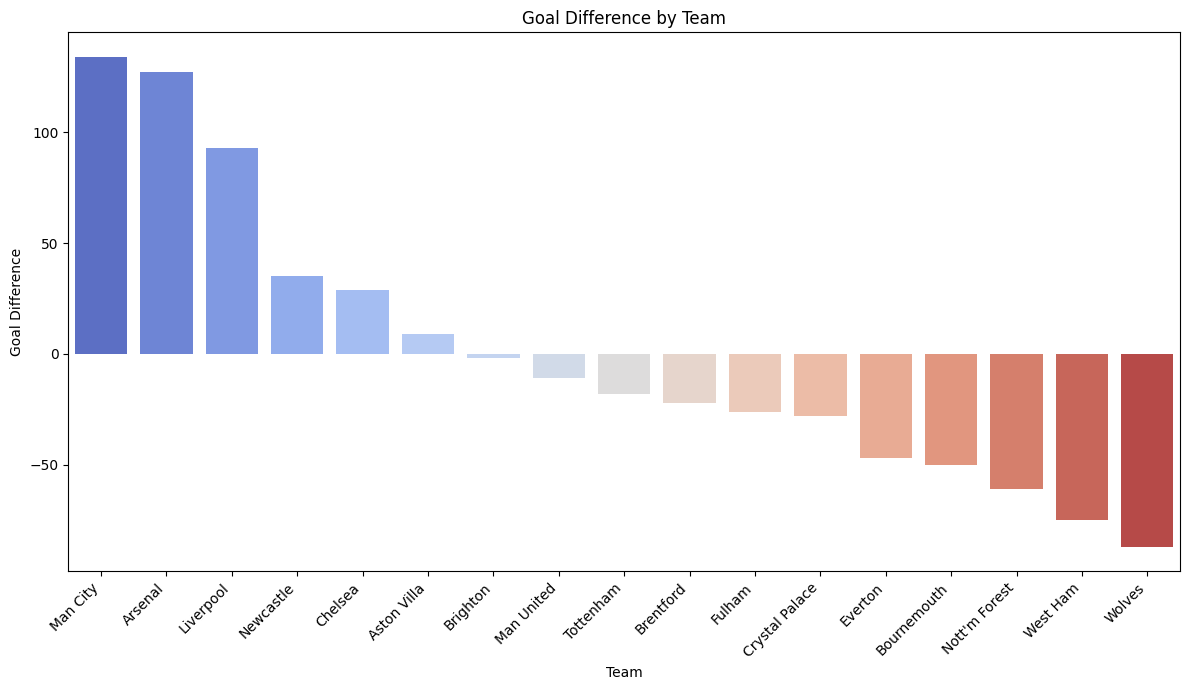

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Team', y='Goal Difference', data=goal_stats_df, palette='coolwarm')
plt.title('Goal Difference by Team')
plt.xlabel('Team')
plt.ylabel('Goal Difference')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Mancity leads has scored 134 more goals than they have been scored while Wolves have been scored 87 more goals than they have scored.